# 01 — One pair, end to end

This notebook follows a single pair through the whole pipeline so every step is visible:
formation-period selection by distance, the spread, four half-life estimators, stationarity /
cointegration tests, and the GGR trading simulation. Everything uses the cached data written by
`experiments/01_data.py` and the library in `src/hlpairs/`.

In [1]:
import os, pathlib
os.chdir(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 160)

In [2]:
from hlpairs import data, halflife as hl, diagnostics as dg
from hlpairs.pairs import normalize, top_pairs
from hlpairs.universe import formation_universe
from hlpairs.backtest import trade_pairs

px = data.load_prices()
membership = data.load_membership("data/raw/sp500_membership.csv")
t0 = pd.Timestamp("2005-01-03")                      # first trading day of the trading period
form_idx = px.index[(px.index >= t0 - pd.DateOffset(months=12)) & (px.index < t0)]
universe = formation_universe(px, membership, form_idx[0], form_idx[-1])
print(len(universe), "stocks eligible (members on formation start, no missing prices)")

256 stocks eligible (members on formation start, no missing prices)


## Step 1 — rank all pairs by distance (SSD)
Prices are normalised to a cumulative total-return index starting at 1, and
$D_{ij} = \sum_t (P^i_t - P^j_t)^2$ is computed for every pair.

In [3]:
form_px = px.loc[form_idx, universe]
form = normalize(form_px)
pairs = top_pairs(form, 20)
pairs.head(10)

,i,j,ssd,sigma
0,SO,AEE,0.106071,0.020560
1,EMR,VMC,0.129206,0.022577
2,XEL,D,0.130691,0.021789
3,WFC,D,0.140748,0.019651
4,XOM,CVX,0.158187,0.023512
5,PG,KMB,0.168111,0.022951
6,AEP,AXP,0.173300,0.026267
7,BF-B,GIS,0.174816,0.025276
8,NOC,GD,0.176734,0.026579
9,XEL,AEE,0.179315,0.026413


## Step 2 — the spread and its half-life
For the best pair, the spread $S_t = P^i_t - P^j_t$ is fitted as an AR(1),
$S_t = c + \phi S_{t-1} + \varepsilon_t$, giving half-life $h = -\ln 2 / \ln \phi$.

In [4]:
i, j, sigma = pairs.loc[0, ["i", "j", "sigma"]]
s = (form[i] - form[j]).to_numpy()
est = {name: f(s) for name, f in hl.ESTIMATORS.items()}
print(f"pair {i}/{j}; phi_OLS = {hl.ar1_phi(s):.3f}")
pd.Series(est, name="half-life (days)").round(2)

pair SO/AEE; phi_OLS = 0.944


ols         12.02
kendall     16.69
ou_mle      11.29
crossing    11.41
Name: half-life (days), dtype: float64

In [5]:
y, x = np.log(form_px[i]), np.log(form_px[j])
pd.Series({"ADF p (spread)": dg.adf_pvalue(s), "KPSS p (spread)": dg.kpss_pvalue(s),
           "Engle-Granger p (log prices)": dg.eg_pvalue(y, x), "Johansen rejects rank 0": dg.johansen_reject(y, x),
           "variance ratio VR(10)": dg.variance_ratio(s)})

ADF p (spread)                  0.223237
KPSS p (spread)                 0.028422
Engle-Granger p (log prices)    0.497563
Johansen rejects rank 0            False
variance ratio VR(10)            0.62247
dtype: object

## Step 3 — trade it for six months
Open when the normalised gap exceeds $2\sigma$ (formation σ), short the rich leg, long the cheap
leg, close when prices cross or at the end of the period.

In [6]:
trade = px.loc[(px.index >= t0) & (px.index < t0 + pd.DateOffset(months=6)), universe]
pnl, legs, active = trade_pairs(trade, pairs.head(1), base=form_px.iloc[0])
log = pd.DataFrame({"legs traded": legs[:, 0], "in position": active[:, 0], "daily P&L": pnl[:, 0]}, index=trade.index)
print("round trips:", legs.sum() / 4, " total P&L per $1:", round(pnl.sum(), 4))
log[log["legs traded"] > 0]

round trips: 1.0  total P&L per $1: -0.0189


,legs traded,in position,daily P&L
2005-02-22,2.0,False,0.000000
2005-07-01,2.0,True,0.006555


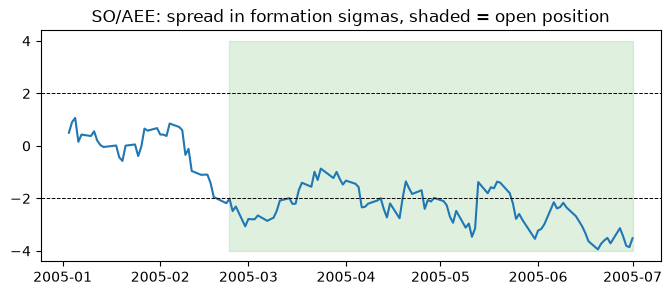

In [7]:
spread = ((trade[i] / form_px[i].iloc[0]) - (trade[j] / form_px[j].iloc[0])) / sigma
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(spread.index, spread); [ax.axhline(v, ls="--", c="k", lw=.7) for v in (2, -2)]
ax.fill_between(spread.index, -4, 4, where=active[:, 0], alpha=.15, color="tab:green")
ax.set(title=f"{i}/{j}: spread in formation sigmas, shaded = open position"); plt.show()